# Predict uncertainty + scenario plots

For every finished storm_draw mean (`storm_draw_*/admin_level_exposure_deaths_mean.parquet`):

1. Aggregate deaths up the GBD hierarchy.
2. Pivot into wide draw form, expand onto the full `(scenario × location × year)` grid, fill 0 only in columns of draws that ran.
3. Add per-row `mean`, `lower` (2.5%), `upper` (97.5%).
4. Write one parquet per `deaths_c{c}_s{s}_o{o}_b{b}` column into `DRAW_BASE/`.
5. Build a consistent 1970–2100 population frame by aggregating level-3 country pops up the hierarchy (the source file has uneven coverage: levels 0–2 are past-only, level 4 is future-only, only level 3 has the full range).
6. Build an observed-deaths frame aggregated up the same hierarchy.
7. Plot per (level-0/1 location) × (deaths column) × (count, rate), with two control flags:
   - `INCLUDE_OBSERVED`: overlay observed-deaths dots from training data.
   - `PLOT_MODE`: `'full'` (historical line + SSPs from 2015) or `'future'` (skip historical line/band, SSPs from `FUTURE_START_YEAR`; observed dots still drawn).

**Toggle semantics** (from `predict/predict_tc.py` + `predict/models.py`):
- `c`, `s` ∈ {0,1} — selector for one of 4 model-pickle variants. Names not labeled in code; edit `TOGGLE_LABELS` below if known.
- `o` = `outcome_draw` (False = expected / True = stochastic draw).
- `b` = `expected_bernoulli` (False = realized / True = expected).


In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from idd_tc_mortality.predict.paths import atomic_write_parquet

# --- Inputs ----------------------------------------------------------------
DRAW_BASE      = Path('/mnt/team/rapidresponse/pub/tropical-storms/direct_risk/storm_draws/')
HIERARCHY_PATH = '/mnt/team/idd/pub/forecast-mbp/01-raw_data/gbd/fhs_2023_modeling_hierarchy.parquet'

# Population source. *** TEMPORARY *** — replace this when scenario-specific population is available.
POP_PATH       = '/mnt/team/rapidresponse/pub/tropical-storms/fhs_population_2021_all_years.parquet'

# Observed-deaths source — the training data the models were fit on.
OBS_PATH       = '/mnt/team/idd/pub/idd_tc_mortality/00-data/current/input.parquet'

# --- Outputs ---------------------------------------------------------------
FIG_DIR        = DRAW_BASE / 'figures' / 'level0_level1_scenarios'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Plotting flags --------------------------------------------------------
INCLUDE_OBSERVED  = False       # overlay observed historical deaths on each plot
PLOT_MODE         = 'future'   # 'full' (historical + SSPs) or 'future' (SSPs from FUTURE_START_YEAR, no historical)
FUTURE_START_YEAR = 2023       # used when PLOT_MODE='future'
RATE_PER          = 100_000    # rate-plot denominator: deaths per RATE_PER people (GBD convention = 100,000)

# --- Constants -------------------------------------------------------------
DEATHS_COLS = [f'deaths_c{c}_s{s}_o{o}_b{b}'
               for c in (0, 1) for s in (0, 1) for o in (0, 1) for b in (0, 1)]
ALL_DRAW_COLS = [f'draw_{i:02d}' for i in range(100)]

YEARS_BY_SCENARIO = {
    'historical': np.arange(1980, 2015),
    'ssp126':     np.arange(2015, 2101),
    'ssp245':     np.arange(2015, 2101),
    'ssp585':     np.arange(2015, 2101),
}

ssp_scenario_map = {
    'ssp126': {'name': 'RCP2.6', 'color': '#046C9A'},
    'ssp245': {'name': 'RCP4.5', 'color': '#E58601'},
    'ssp585': {'name': 'RCP8.5', 'color': '#A42820'},
}

TOGGLE_LABELS = {
    'c': {'name': 'c',         0: '0', 1: '1'},
    's': {'name': 's',         0: '0', 1: '1'},
    'o': {'name': 'outcome',   0: 'expected', 1: 'stochastic'},
    'b': {'name': 'bernoulli', 0: 'realized', 1: 'expected'},
}

In [2]:
# Hierarchy: ancestor map (each row's path_to_top_parent lists itself + all ancestors)
hierarchy_df = pd.read_parquet(HIERARCHY_PATH)
ancestor_map = (
    hierarchy_df[['location_id', 'path_to_top_parent']]
    .assign(ancestor=lambda d: d['path_to_top_parent'].str.split(','))
    .explode('ancestor')[['location_id', 'ancestor']]
    .astype({'ancestor': int})
)

# Full grid: levels 0–3 only, scenario-specific years
ALL_LOCATION_IDS = np.sort(
    hierarchy_df.loc[hierarchy_df['level'] <= 3, 'location_id'].unique()
)
grid = pd.concat([
    pd.MultiIndex.from_product(
        [[s], ALL_LOCATION_IDS, yrs],
        names=['scenario', 'location_id', 'year'],
    ).to_frame(index=False)
    for s, yrs in YEARS_BY_SCENARIO.items()
], ignore_index=True)
print(f'grid: {len(grid):,} rows ({len(ALL_LOCATION_IDS)} locations × scenario-specific years)')

grid: 68,269 rows (233 locations × scenario-specific years)


In [3]:
# Per-draw: load most-detailed deaths, aggregate up the hierarchy, tag with draw column.
frames              = []
finished_draw_cols  = []
for d in sorted(p for p in DRAW_BASE.iterdir()
                if p.is_dir() and p.name.startswith('storm_draw_')):
    mean_path = d / 'admin_level_exposure_deaths_mean.parquet'
    if not mean_path.exists():
        continue
    sd = int(d.name.split('_')[-1])
    draw_col = f'draw_{sd - 1:02d}'

    df = pd.read_parquet(
        mean_path,
        columns=['scenario', 'location_id', 'year'] + DEATHS_COLS,
    )
    missing = set(df['location_id'].unique()) - set(ancestor_map['location_id'].unique())
    if missing:
        raise ValueError(f'storm_draw {sd}: location_ids not in hierarchy: {missing}')

    df = (
        df.merge(ancestor_map, on='location_id')
          .drop(columns='location_id')
          .rename(columns={'ancestor': 'location_id'})
          .groupby(['scenario', 'location_id', 'year'], as_index=False)[DEATHS_COLS]
          .sum()
    )
    df['draw'] = draw_col
    frames.append(df)
    finished_draw_cols.append(draw_col)

print(f'loaded + aggregated {len(frames)} storm_draws')
long = pd.concat(frames, ignore_index=True)

loaded + aggregated 87 storm_draws


In [4]:
# Pivot each deaths column, expand to grid, fill 0 only in finished draws, add summary cols, save.
for col in DEATHS_COLS:
    wide = (
        long.pivot(
            index=['scenario', 'location_id', 'year'],
            columns='draw',
            values=col,
        )
        .reindex(columns=ALL_DRAW_COLS)
        .reset_index()
    )
    wide.columns.name = None
    wide = grid.merge(wide, on=['scenario', 'location_id', 'year'], how='left')
    wide[finished_draw_cols] = wide[finished_draw_cols].fillna(0.0)

    arr = wide[ALL_DRAW_COLS].to_numpy()
    wide['mean']  = np.nanmean(arr, axis=1)
    wide['lower'] = np.nanpercentile(arr, 2.5,  axis=1)
    wide['upper'] = np.nanpercentile(arr, 97.5, axis=1)
    wide = wide[['scenario', 'location_id', 'year', 'mean', 'lower', 'upper'] + ALL_DRAW_COLS]

    out_path = DRAW_BASE / f'{col}_draws.parquet'
    atomic_write_parquet(wide, out_path)
    print(f'{col}: {len(wide):,} rows written -> {out_path.name}')

deaths_c0_s0_o0_b0: 68,269 rows written -> deaths_c0_s0_o0_b0_draws.parquet
deaths_c0_s0_o0_b1: 68,269 rows written -> deaths_c0_s0_o0_b1_draws.parquet
deaths_c0_s0_o1_b0: 68,269 rows written -> deaths_c0_s0_o1_b0_draws.parquet
deaths_c0_s0_o1_b1: 68,269 rows written -> deaths_c0_s0_o1_b1_draws.parquet
deaths_c0_s1_o0_b0: 68,269 rows written -> deaths_c0_s1_o0_b0_draws.parquet
deaths_c0_s1_o0_b1: 68,269 rows written -> deaths_c0_s1_o0_b1_draws.parquet
deaths_c0_s1_o1_b0: 68,269 rows written -> deaths_c0_s1_o1_b0_draws.parquet
deaths_c0_s1_o1_b1: 68,269 rows written -> deaths_c0_s1_o1_b1_draws.parquet
deaths_c1_s0_o0_b0: 68,269 rows written -> deaths_c1_s0_o0_b0_draws.parquet
deaths_c1_s0_o0_b1: 68,269 rows written -> deaths_c1_s0_o0_b1_draws.parquet
deaths_c1_s0_o1_b0: 68,269 rows written -> deaths_c1_s0_o1_b0_draws.parquet
deaths_c1_s0_o1_b1: 68,269 rows written -> deaths_c1_s0_o1_b1_draws.parquet
deaths_c1_s1_o0_b0: 68,269 rows written -> deaths_c1_s1_o0_b0_draws.parquet
deaths_c1_s1

In [5]:
# Population: use level-3 country pops (the only level with full 1970–2100 coverage)
# and aggregate up the hierarchy. Source file has uneven coverage:
#   levels 0/1/2 → 1970–2022 only, level 4 → 2023–2100 only, level 3 → 1970–2100.
# Aggregating from level 3 gives consistent coverage at every level we plot.
pop_raw = pd.read_parquet(POP_PATH)
pop_raw = pop_raw[(pop_raw['age_group_id'] == 22) & (pop_raw['sex_id'] == 3)]
pop_raw = pop_raw.rename(columns={'year_id': 'year'})[['location_id', 'year', 'population']]

country_pop = (
    pop_raw
    .merge(hierarchy_df[['location_id', 'level']], on='location_id')
    .query('level == 3')
    .drop(columns='level')
)
pop = (
    country_pop
    .merge(ancestor_map, on='location_id')
    .drop(columns='location_id')
    .rename(columns={'ancestor': 'location_id'})
    .groupby(['location_id', 'year'], as_index=False)['population'].sum()
    .query('location_id in @ALL_LOCATION_IDS')
    .reset_index(drop=True)
)
atomic_write_parquet(pop, DRAW_BASE / 'population.parquet')
print(f'population: {len(pop):,} rows '
      f'({pop["location_id"].nunique()} locations × {pop["year"].nunique()} years '
      f'[{pop["year"].min()}–{pop["year"].max()}])')

population: 30,523 rows (233 locations × 131 years [1970–2100])


In [6]:
# Observed deaths: load training data (the file the models were fit on), aggregate up the hierarchy.
obs_raw = pd.read_parquet(OBS_PATH, columns=['location_id', 'year', 'deaths'])
obs = (
    obs_raw
    .groupby(['location_id', 'year'], as_index=False)['deaths'].sum()  # collapse storm dim
    .merge(ancestor_map, on='location_id')
    .drop(columns='location_id')
    .rename(columns={'ancestor': 'location_id'})
    .groupby(['location_id', 'year'], as_index=False)['deaths'].sum()  # roll up to ancestors
)
print(f'observed: {len(obs):,} rows '
      f'({obs["location_id"].nunique()} locations × years {obs["year"].min()}–{obs["year"].max()})')

observed: 1,964 rows (114 locations × years 1980–2021)


## Scenario plots

Flags at the top control:
- `INCLUDE_OBSERVED` — overlay observed-deaths dots. Filename tag: `obs` / `noobs`.
- `PLOT_MODE`       — `'full'` (default; historical line + SSPs from 2015) or `'future'` (no historical line/band; SSPs start at `FUTURE_START_YEAR`; observed dots still shown). Filename tag: `full` / `future`.

8 level-0/1 locations × 16 toggles × 2 spaces = 256 figures per run; flip a flag and re-run for a different set (filenames carry the flag tags so re-runs don't overwrite).

In [138]:
def _decode_toggle(deaths_col: str) -> str:
    """deaths_c0_s1_o1_b0 -> 'c=0, s=1, outcome=stochastic, bernoulli=realized'."""
    parts = deaths_col.replace('deaths_', '').split('_')
    out = []
    for p in parts:
        key = p[0]
        val = int(p[1:])
        lbl = TOGGLE_LABELS[key]
        out.append(f"{lbl['name']}={lbl[val]}")
    return ', '.join(out)


def _safe_filename(s: str) -> str:
    return s.replace(' ', '_').replace('/', '_').replace(',', '').replace("'", '')


def _rate_ylabel(rate_per: int) -> str:
    if rate_per == 1:
        return 'Mean death rate (deaths per person, 95% UI)'
    return f'Mean death rate (per {rate_per:,}, 95% UI)'


def plot_scenario_panel(
    location_id: int, location_name: str, deaths_col: str,
    space: str = 'count',
    include_observed: bool = INCLUDE_OBSERVED,
    mode: str = PLOT_MODE,
    future_start_year: int = FUTURE_START_YEAR,
    rate_per: int = RATE_PER,
    fig_dir: Path = FIG_DIR,
) -> Path:
    """Single-panel plot.

    space             : 'count' (mean deaths) or 'rate' (deaths / population × rate_per).
    include_observed  : overlay observed-deaths dots in matching units.
    mode              : 'full'   → historical line/band + SSPs from 2015.
                        'future' → no historical line/band; SSPs only from
                                   `future_start_year` onward. Observed dots are
                                   still drawn for all years they exist.
    rate_per          : rate denominator (e.g., 100_000 → deaths per 100,000).
    """
    if space not in ('count', 'rate'):
        raise ValueError(f"space must be 'count' or 'rate', got {space!r}")
    if mode not in ('full', 'future'):
        raise ValueError(f"mode must be 'full' or 'future', got {mode!r}")

    df = pd.read_parquet(
        DRAW_BASE / f'{deaths_col}_draws.parquet',
        columns=['scenario', 'location_id', 'year', 'mean', 'lower', 'upper'],
    )
    sub = df[df['location_id'] == location_id].copy()

    if space == 'rate':
        sub = sub.merge(pop, on=['location_id', 'year'], how='left')
        for c in ('mean', 'lower', 'upper'):
            sub[c] = sub[c] / sub['population'] * rate_per
        ylabel = _rate_ylabel(rate_per)
    else:
        ylabel = 'Mean deaths (95% UI)'

    fig, ax = plt.subplots(figsize=(9, 5))

    # Historical scenario line/band — only in 'full' mode.
    if mode == 'full':
        h = sub[sub['scenario'] == 'historical'].sort_values('year')
        if not h.empty:
            ax.plot(h['year'], h['mean'], color='black', label='Historical', lw=1.5)
            ax.fill_between(h['year'], h['lower'], h['upper'],
                            color='black', alpha=0.2, linewidth=0)

    # SSP lines/bands — in 'future' mode, trim to year >= future_start_year.
    for ssp, info in ssp_scenario_map.items():
        s = sub[sub['scenario'] == ssp].sort_values('year')
        if mode == 'future':
            s = s[s['year'] >= future_start_year]
        if s.empty:
            continue
        ax.plot(s['year'], s['mean'], color=info['color'], label=info['name'], lw=1.5)
        ax.fill_between(s['year'], s['lower'], s['upper'],
                        color=info['color'], alpha=0.2, linewidth=0)

    # Observed dots (always full range when included).
    if include_observed:
        obs_loc = obs[obs['location_id'] == location_id].copy()
        if not obs_loc.empty:
            if space == 'rate':
                obs_loc = obs_loc.merge(pop, on=['location_id', 'year'], how='left')
                obs_y = obs_loc['deaths'] / obs_loc['population'] * rate_per
            else:
                obs_y = obs_loc['deaths']
            ax.scatter(
                obs_loc['year'], obs_y,
                color='black', s=18, zorder=5,
                edgecolor='white', linewidths=0.6,
                label='Observed',
            )

    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{location_name}  [{space}, {mode}]\n{_decode_toggle(deaths_col)}')
    # Legend parked outside the axes so it never overlaps the data.
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False)
    ax.grid(alpha=0.3)
    ax.margins(x=0.01)
    fig.tight_layout()

    obs_tag = 'obs' if include_observed else 'noobs'
    out_path = fig_dir / f'{_safe_filename(location_name)}__{deaths_col}__{space}_{obs_tag}_{mode}.png'
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    return out_path

In [8]:
target_locs = (
    hierarchy_df.loc[hierarchy_df['level'].isin([0, 1]),
                     ['location_id', 'location_name', 'level']]
    .sort_values(['level', 'location_id'])
    .reset_index(drop=True)
)
print(f'{len(target_locs)} target locations × {len(DEATHS_COLS)} toggles × 2 spaces '
      f'= {len(target_locs) * len(DEATHS_COLS) * 2} figures '
      f'(INCLUDE_OBSERVED={INCLUDE_OBSERVED}, PLOT_MODE={PLOT_MODE})')
target_locs

8 target locations × 16 toggles × 2 spaces = 256 figures (INCLUDE_OBSERVED=True, PLOT_MODE=future)


,location_id,location_name,level
0,1,Global,0
1,4,"Southeast Asia, East Asia, and Oceania",1
2,31,"Central Europe, Eastern Europe, and Central Asia",1
3,64,High-income,1
4,103,Latin America and Caribbean,1
5,137,North Africa and Middle East,1
6,158,South Asia,1
7,166,Sub-Saharan Africa,1


In [139]:
for _, loc_row in target_locs.iterrows():
    for col in DEATHS_COLS:
        for space in ('count', 'rate'):
            plot_scenario_panel(
                int(loc_row['location_id']),
                str(loc_row['location_name']),
                col,
                space=space,
                include_observed=INCLUDE_OBSERVED,
                rate_per=RATE_PER,
                mode=PLOT_MODE,
            )
    print(f'done: {loc_row["location_name"]}')

print(f'\nall figures -> {FIG_DIR}')

done: Global
done: Southeast Asia, East Asia, and Oceania
done: Central Europe, Eastern Europe, and Central Asia
done: High-income
done: Latin America and Caribbean
done: North Africa and Middle East
done: South Asia
done: Sub-Saharan Africa

all figures -> /mnt/team/rapidresponse/pub/tropical-storms/direct_risk/storm_draws/figures/level0_level1_scenarios


---
## Exploration / diagnostics

Preserved from the in-session investigation of the Mozambique 1984 spike.

In [107]:

death_col = 'deaths_c0_s0_o0_b0'
path = DRAW_BASE / f'{death_col}_draws.parquet'
df = pd.read_parquet(path)
df = df.merge(hierarchy_df[['location_id', 'location_name', 'level']], on='location_id', how='left')
old_df = df[df['year'] < 1985].copy()
old_df = old_df[old_df['level'] == 3]
old_df[old_df['mean'] == old_df['mean'].max()]
location_id = old_df[old_df['mean'] == old_df['mean'].max()]['location_id'].iloc[0]
print(location_id)

184


In [109]:
df[(df['year'] >= 2020) & (df['year'] <= 2021)]

,scenario,location_id,year,mean,lower,upper,draw_00,draw_01,draw_02,draw_03,...,draw_92,draw_93,draw_94,draw_95,draw_96,draw_97,draw_98,draw_99,location_name,level
8160,ssp126,1,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,Global,0
8161,ssp126,1,2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,Global,0
8246,ssp126,4,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,"Southeast Asia, East Asia, and Oceania",1
8247,ssp126,4,2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,"Southeast Asia, East Asia, and Oceania",1
8332,ssp126,5,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,East Asia,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68017,ssp585,422,2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,United States Virgin Islands,3
68102,ssp585,435,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,South Sudan,3
68103,ssp585,435,2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,South Sudan,3
68188,ssp585,522,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,Sudan,3


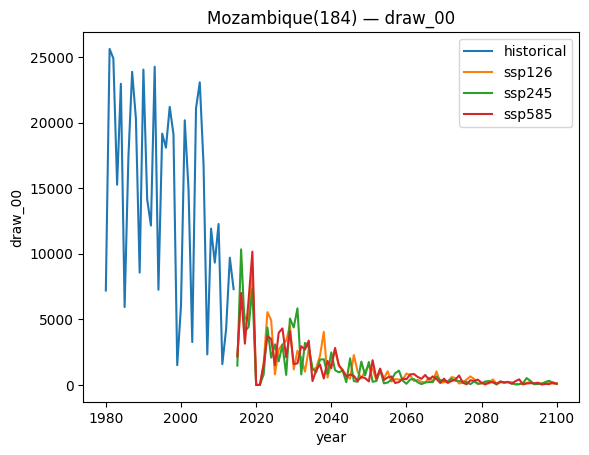

In [51]:
# Plot year vs draw_00 for Mozambique (location_id 184)
sub = df[df['location_id'] == location_id][['scenario', 'year', 'draw_00', 'location_name']]
for scenario, grp in sub.groupby('scenario'):
    plt.plot(grp['year'], grp['draw_00'], label=scenario)
plt.xlabel('year')
plt.ylabel('draw_00')
plt.title(f"{sub['location_name'].iloc[0]}({location_id}) — draw_00")
plt.legend()
plt.show()

In [126]:
time_bins_path = '/mnt/team/rapidresponse/pub/tropical-storms/tempestextremes/outputs/cmip6/bayespoisson_time_bins_max_bin_5.csv'
storm_draw_table_path = '/mnt/team/rapidresponse/pub/tropical-storms/storm_draw_table.csv'
CLIMADA_OUTPUT_BASE = Path('/mnt/team/rapidresponse/pub/tropical-storms/climada/output/stage4_v2')

storm_draw = 1
year = 2020
scenario = 'historical' if year < 2015 else 'ssp585'

time_bins_df = pd.read_csv(time_bins_path)
storm_draw_table_df = pd.read_csv(storm_draw_table_path)
row_df = storm_draw_table_df[storm_draw_table_df['storm_draw'] == storm_draw]
model = row_df['source_id'].iloc[0]
variant = row_df['variant_label'].iloc[0]
model_time_bins_df = time_bins_df[(time_bins_df['model'] == model) &(time_bins_df['variant'] == variant) & 
                                  (time_bins_df['start_year'] <= year) & (time_bins_df['end_year'] >= year)]
start_year = model_time_bins_df['start_year'].iloc[0]
end_year = model_time_bins_df['end_year'].iloc[0]

year_bin = f'{start_year}-{end_year}'
time_bin_base = CLIMADA_OUTPUT_BASE / model / variant / scenario / year_bin
basins = sorted(
    p.name
    for p in time_bin_base.iterdir()
    if p.is_dir()
)

In [127]:
def get_tc_draw_suffix(draw: int) -> str:
    return '' if draw == 0 else f'_e{draw-1}'
    
def get_admin_path(admin_df_path: Path, model: str, variant: str, scenario: str, year_bin: str, basin: str, draw: int) -> Path:
    tc_draw_suffix = get_tc_draw_suffix(draw)
    year_start, year_end = map(int, year_bin.split('-'))
    return admin_df_path / f'admin_level_exposure_{basin}_{model}_{variant}_{scenario}_{year_start}01_{year_end}12{tc_draw_suffix}.parquet'

new_sdi_df_path = '/mnt/share/forecasting/data/9/future/sdi/future_sdi_s131v3/sdi.nc'
old_sdi_df_path = '/mnt/share/forecasting/data/9/past/sdi/past_sdi_s131v3/sdi.nc'
storm_draw_table_path = '/mnt/team/rapidresponse/pub/tropical-storms/storm_draw_table.csv'
island_cov_path = '/mnt/team/rapidresponse/pub/tropical-storms/climada/output/stage4_v2/island_cov.parquet'

time_bins_path = '/mnt/team/rapidresponse/pub/tropical-storms/tempestextremes/outputs/cmip6/bayespoisson_time_bins_max_bin_5.csv'
time_bins_df = pd.read_csv(time_bins_path)
time_bins_df = time_bins_df[time_bins_df['start_year'] >= 1970].copy()
time_bins_df = time_bins_df[['model', 'variant', 'scenario', 'method', 'bin_idx', 'start_year', 'end_year']].drop_duplicates()

import xarray as xr
def get_sdi_df(year_bin: str, location_ids: list) -> pd.DataFrame:
    year_start, year_end = map(int, year_bin.split('-'))
    if year_end <= 2021:
        ds = xr.open_dataset(old_sdi_df_path).sel(year_id = slice(year_start, max(year_end, 1980)))
        if year_start < 1980:
            # Duplicate 1980 data to fill in year_start-1979, since the old SDI dataset only has data from 1980 onwards
            ds_1980 = ds.sel(year_id=1980)
            ds_1970s = ds_1980.expand_dims(year_id=np.arange(year_start, 1980)).assign_coords(year_id=np.arange(year_start, 1980))
            ds = xr.concat([ds_1970s, ds], dim='year_id').sel(year_id=slice(year_start, year_end))
    elif year_start < 2020:
        ds_old = xr.open_dataset(old_sdi_df_path).sel(year_id = slice(year_start, year_end))
        ds_new = xr.open_dataset(new_sdi_df_path).sel(year_id = slice(year_start, year_end)).squeeze('scenario', drop=True)
        ds = xr.concat([ds_old, ds_new], dim='year_id').sortby('year_id')
    else:
        ds = xr.open_dataset(new_sdi_df_path).sel(year_id = slice(year_start, year_end)).squeeze('scenario', drop=True)
    
    if location_ids:
        ds = ds.sel(location_id = location_ids)
    sdi_mean = ds['draws'].mean(dim='draw')
    sdi_df = sdi_mean.to_dataframe(name='sdi').reset_index().rename(columns={'year_id': 'year'})
    return sdi_df

In [133]:
old_sdi_df = xr.open_dataset(old_sdi_df_path)
old_sdi_df

<xarray.Dataset> Size: 81MB
Dimensions:      (draw: 500, location_id: 482, year_id: 42)
Coordinates:
  * draw         (draw) int64 4kB 0 1 2 3 4 5 6 ... 493 494 495 496 497 498 499
  * location_id  (location_id) int64 4kB 33 34 35 36 37 ... 215 216 217 218
  * year_id      (year_id) int64 336B 1980 1981 1982 1983 ... 2019 2020 2021
Data variables:
    draws        (draw, location_id, year_id) float64 81MB ...

In [128]:
def find_basin(location_id: int, time_bin_base: Path) -> str:
    """Find the basin for a given location_id by checking which time bin file it appears in."""
    found_basin = None
    # while found basin is None: start with draw_0 and go up until draw_99. For each draw, check each basin one by one for the location_id. If found, return the basin name (the part after 'time_bins_'). If not found in any basin, return 'unknown'.
    draw_num = 0
    while found_basin is None and draw_num < 100:
        print(f'Checking draw {draw_num} for location_id {location_id}...')
        for basin in basins:
            df_path = get_admin_path(
                admin_df_path=time_bin_base / basin / 'admin_level_exposure',
                model=model,
                variant=variant,
                scenario='historical',
                year_bin=f'{start_year}-{end_year}',
                basin=basin,
                draw=draw_num,
            )
            if not df_path.exists():
                continue
            df = pd.read_parquet(df_path, columns=['location_id'])
            if location_id in df['location_id'].values:
                found_basin = basin
                break
        draw_num += 1
    if found_basin is None:
        print(f'Location_id {location_id} not found in any basin for draws 0-99.')
        return 'unknown'
    print(f'Location_id {location_id} found in basin {found_basin} on draw {draw_num-1}.')
    return found_basin

In [131]:
found_basin = []
for basin in basins:
    df_path = f'/mnt/team/rapidresponse/pub/tropical-storms/direct_risk/storm_draws/storm_draw_1/{scenario}/{year_bin}/{basin}/admin_level_exposure_deaths_mean.parquet'
    df = pd.read_parquet(df_path)
    if not df[df["location_id"] == location_id].empty:
        found_basin.append(basin)
    print(f'Basin: {basin}, Shape: {df[df["location_id"] == location_id].shape}')
if len(found_basin) == 0:
    print(f'Location_id {location_id} not found in any basin.')
elif len(found_basin) == 1:
    print(f'Location_id {location_id} found in basin: {found_basin[0]}')
    found_basin = found_basin[0]
else:
    print(f'Location_id {location_id} found in multiple basins: {found_basin}')

Basin: AU, Shape: (0, 21)
Basin: EP, Shape: (0, 21)
Basin: NA, Shape: (0, 21)
Basin: NI, Shape: (0, 21)
Basin: SI, Shape: (3, 21)
Basin: SP, Shape: (0, 21)
Basin: WP, Shape: (0, 21)
Location_id 184 found in basin: SI


In [132]:
sub[(sub['year'] >= start_year) & (sub['year'] <= end_year) & (sub['scenario'] == scenario)]

,scenario,year,draw_00,location_name
63802,ssp585,2020,0.000000,Mozambique
63803,ssp585,2021,0.000000,Mozambique
63804,ssp585,2022,1556.706563,Mozambique
63805,ssp585,2023,3719.266576,Mozambique
63806,ssp585,2024,3502.044192,Mozambique


In [66]:
basin_df_path = f'/mnt/team/rapidresponse/pub/tropical-storms/direct_risk/storm_draws/storm_draw_1/historical/1980-1984/{found_basin}/admin_level_exposure_deaths_mean.parquet'
basin_df = pd.read_parquet(basin_df_path)
sub_df = basin_df[basin_df['location_id'] == location_id][['location_id', 'year', death_col]]
sub_df

,location_id,year,deaths_c0_s0_o0_b0
45,184,1980,7200.132625
46,184,1981,25618.466932
47,184,1982,24892.361113
48,184,1983,15263.733153
49,184,1984,22961.132279


In [67]:
year = sub_df[sub_df[death_col] == sub_df[death_col].max()]['year'].iloc[0]
print(year)

1981


In [75]:
tc_risk_draw_dirs = sorted(p for p in (CLIMADA_OUTPUT_BASE / model / variant / 'historical' / f'{start_year}-{end_year}' / found_basin).iterdir() if p.is_dir())

In [85]:
storm_data = []
for draw_dir in tc_risk_draw_dirs:
    draw_num = int(draw_dir.name.split('_')[-1])
    admin_path = get_admin_path(
        admin_df_path=draw_dir / 'admin_level_exposure',
        model=model,
        variant=variant,
        scenario='historical',
        year_bin=f'{start_year}-{end_year}',
        basin=found_basin,
        draw=draw_num,
    )
    if not admin_path.exists():
        print(f'Admin path {admin_path} does not exist, skipping.')
        continue
    df = pd.read_parquet(admin_path)
    df = df[(df['location_id'] == location_id) & (df['year'] == year)]
    if df.empty:
        print(f'No data for location_id {location_id} in draw {draw_num}, skipping.')
        continue
    storm_data.append(df)
storm_data_df = pd.concat(storm_data, ignore_index=True)

No data for location_id 184 in draw 19, skipping.
No data for location_id 184 in draw 26, skipping.
No data for location_id 184 in draw 54, skipping.


In [88]:
(storm_data_df['person_storm_hours'] / storm_data_df['total_population_exposed']).max()

34.64394354446221

In [105]:
tc_risk_draw_num = 0
tc_risk_draw_suffix = get_tc_draw_suffix(tc_risk_draw_num)
storm_data_df[storm_data_df['draw'] == tc_risk_draw_num]

df_path = f'/mnt/team/rapidresponse/pub/tropical-storms/direct_risk/storm_draws/storm_draw_1/historical/1980-1984/SI/admin_level_exposure_deaths{tc_risk_draw_suffix}.parquet'
df = pd.read_parquet(df_path)
df = df[(df['location_id'] == location_id) & (df['year'] == year)]
sdi = get_sdi_df(year_bin=f'{start_year}-{end_year}', location_ids=[location_id])
df = df.merge(sdi, on=['location_id', 'year'], how='left')
df

,location_id,year,basin,exposed,total_population,deaths_c0_s0_o0_b0,deaths_c0_s0_o0_b1,deaths_c0_s0_o1_b0,deaths_c0_s0_o1_b1,deaths_c0_s1_o0_b0,...,deaths_c0_s1_o1_b1,deaths_c1_s0_o0_b0,deaths_c1_s0_o0_b1,deaths_c1_s0_o1_b0,deaths_c1_s0_o1_b1,deaths_c1_s1_o0_b0,deaths_c1_s1_o0_b1,deaths_c1_s1_o1_b0,deaths_c1_s1_o1_b1,sdi
0,184,1981,SI,1680894.375,1.254765e+07,0.0,3314.341079,0.0,12.069102,0.0,...,12.02352,0.0,3568.176589,0.0,10.263713,0.0,3568.176589,0.0,10.2441,0.1489


,location_id,year,sdi
0,184,1980,0.146580
1,184,1981,0.148900
2,184,1982,0.150790
3,184,1983,0.151464
4,184,1984,0.152213


In [104]:
death_col

'deaths_c0_s0_o0_b0'

In [141]:
obs_df = obs_raw.groupby(['year'], as_index=False)['deaths'].sum()  # collapse storm dim
obs_df.mean()


year      2000.500000
deaths    9022.142857
dtype: float64